# Import data

In [1]:
import pandas as pd
import numpy as np
from statsbombpy import sb
from mplsoccer import Pitch
import matplotlib.pyplot as plt
import seaborn as sns
from ipywidgets import interact, fixed
%matplotlib inline

from matplotlib.patches import FancyArrowPatch
from matplotlib.lines import Line2D
from collections import defaultdict
from pathlib import Path

pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', 1000)        # To avoid linebreaks
pd.set_option('display.max_rows', None)

In [2]:
sb.competitions().head()

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-07-06T04:26:07.636270,2025-07-06T04:26:07.636270,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,NaN,NaN,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2024-09-28T01:57:35.846538,NaN,NaN,2024-09-28T01:57:35.846538
3,16,4,Europe,Champions League,male,False,False,2018/2019,2025-05-08T15:10:50.835274,2021-06-13T16:17:31.694,NaN,2025-05-08T15:10:50.835274
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,NaN,2024-02-13T02:35:28.134882


In [3]:
sb.competitions()[sb.competitions()['match_available_360'].notna()]

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-07-06T04:26:07.636270,2025-07-06T04:26:07.636270,2024-09-28T20:46:38.893391
29,43,106,International,FIFA World Cup,male,False,True,2022,2024-12-16T10:15:11.055845,2024-12-16T10:21:13.710934,2024-12-16T10:21:13.710934,2024-12-16T10:15:11.055845
38,11,90,Spain,La Liga,male,False,False,2020/2021,2025-01-29T17:39:28.924386,2025-01-29T18:09:18.620699,2025-01-29T18:09:18.620699,2025-01-29T17:39:28.924386
58,7,235,France,Ligue 1,male,False,False,2022/2023,2024-12-19T13:56:45.683863,2025-06-30T02:31:32.046070,2025-06-30T02:31:32.046070,2024-12-19T13:56:45.683863
59,7,108,France,Ligue 1,male,False,False,2021/2022,2025-06-15T12:56:15.594872,2025-06-15T13:02:45.341609,2025-06-15T13:02:45.341609,2025-06-15T12:56:15.594872
61,44,107,United States of America,Major League Soccer,male,False,False,2023,2025-06-15T12:48:12.599307,2025-07-01T11:17:29.514495,2025-07-01T11:17:29.514495,2025-06-15T12:48:12.599307
68,55,282,Europe,UEFA Euro,male,False,True,2024,2024-09-28T16:51:20.698794,2025-03-24T14:12:30.785094,2025-03-24T14:12:30.785094,2024-09-28T16:51:20.698794
69,55,43,Europe,UEFA Euro,male,False,True,2020,2024-07-31T12:29:15.702309,2024-07-31T12:30:57.587087,2024-07-31T12:30:57.587087,2024-07-31T12:29:15.702309
71,53,315,Europe,UEFA Women's Euro,female,False,True,2025,2025-07-28T14:19:20.467348,2025-07-29T16:03:07.355174,2025-07-29T16:03:07.355174,2025-07-28T14:19:20.467348
72,53,106,Europe,UEFA Women's Euro,female,False,True,2022,2024-02-13T13:27:17.178263,2024-02-13T13:30:52.820588,2024-02-13T13:30:52.820588,2024-02-13T13:27:17.178263


In [4]:
dfRaw=sb.matches(competition_id=55, season_id=282)
dfRaw

,match_id,match_date,kick_off,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,competition_id,competition_country_name,competition_name,competition,season_id,season,home_team_id,home_team,home_team_gender,home_team_group,home_team_country_id,home_team_country_name,away_team_id,away_team,away_team_gender,away_team_group,away_team_country_id,away_team_country_name,competition_stage_id,competition_stage,stadium_id,stadium,stadium_country_id,stadium_country_name,referee_id,referee,referee_country_id,referee_country_name,home_managers,away_managers,home_manager_id,home_manager_name,home_manager_nickname,home_manager_dob,home_manager_country_id,home_manager_country_name,away_manager_id,away_manager_name,away_manager_nickname,away_manager_dob,away_manager_country_id,away_manager_country_name,data_version,shot_fidelity_version,xy_fidelity_version
0,3942819,2024-07-10,22:00:00.000,1,2,available,available,2024-07-15T07:54:23.583297,2024-07-15T07:57:36.684453,6,55,Europe,UEFA Euro,Europe - UEFA Euro,282,2024,941,Netherlands,male,None,160,Netherlands,768,England,male,None,68,England,15,Semi-finals,373,Signal-Iduna-Park,85,Germany,241,Felix Zwayer,85,Germany,Ronald Koeman,Gareth Southgate,676,Ronald Koeman,NaN,1963-03-21,160,Netherlands,277,Gareth Southgate,NaN,1970-09-03,68,England,1.1.0,2,2
1,3943043,2024-07-14,22:00:00.000,2,1,available,available,2024-07-15T15:48:50.315500,2024-07-15T15:52:24.778809,7,55,Europe,UEFA Euro,Europe - UEFA Euro,282,2024,772,Spain,male,None,214,Spain,768,England,male,None,68,England,26,Final,367,Olympiastadion Berlin,85,Germany,79,François Letexier,78,France,Luis de la Fuente Castillo,Gareth Southgate,5588,Luis de la Fuente Castillo,Luis de la Fuente,1961-06-21,214,Spain,277,Gareth Southgate,NaN,1970-09-03,68,England,1.1.0,2,2
2,3942752,2024-07-09,22:00:00.000,2,1,available,available,2024-07-10T08:51:07.032303,2024-07-10T13:01:26.597509,6,55,Europe,UEFA Euro,Europe - UEFA Euro,282,2024,772,Spain,male,None,214,Spain,771,France,male,None,78,France,15,Semi-finals,4867,Allianz Arena,85,Germany,943,Slavko Vinčić,208,Slovenia,Luis de la Fuente Castillo,Didier Deschamps,5588,Luis de la Fuente Castillo,Luis de la Fuente,1961-06-21,214,Spain,545,Didier Deschamps,NaN,1968-10-15,78,France,1.1.0,2,2
3,3942382,2024-07-06,22:00:00.000,2,1,available,available,2024-07-10T06:50:04.068615,2024-07-10T06:56:35.146850,5,55,Europe,UEFA Euro,Europe - UEFA Euro,282,2024,941,Netherlands,male,None,160,Netherlands,909,Turkey,male,None,233,Turkey,11,Quarter-finals,367,Olympiastadion Berlin,85,Germany,76,Clément Turpin,78,France,Ronald Koeman,Vincenzo Montella,676,Ronald Koeman,NaN,1963-03-21,160,Netherlands,232,Vincenzo Montella,NaN,1974-06-18,112,Italy,1.1.0,2,2
4,3942349,2024-07-05,22:00:00.000,0,0,available,available,2024-07-12T01:57:15.210934,2024-07-12T02:00:16.871522,5,55,Europe,UEFA Euro,Europe - UEFA Euro,282,2024,780,Portugal,male,None,183,Portugal,771,France,male,None,78,France,11,Quarter-finals,379,Volksparkstadion,85,Germany,1,Michael Oliver,68,England,Roberto Martínez Montoliú,Didier Deschamps,263,Roberto Martínez Montoliú,Roberto Martínez,1973-07-13,214,Spain,545,Didier Deschamps,NaN,1968-10-15,78,France,1.1.0,2,2
5,3930180,2024-06-25,19:00:00.000,2,3,available,available,2024-07-11T13:24:55.422159,2024-07-11T13:25:37.289456,3,55,Europe,UEFA Euro,Europe - UEFA Euro,282,2024,941,Netherlands,male,None,160,Netherlands,915,Austria,male,None,15,Austria,10,Group Stage,367,Olympiastadion Berlin,85,Germany,941,Ivan Kružliak,207,Slovakia,Ronald Koeman,Ralf Rangnick,676,Ronald Koeman,NaN,1963-03-21,160,Netherlands,380,Ralf Rangnick,NaN,1958-06-29,85,Germany,1.1.0,2,2
6,3930171,2024-06-20,19:00:00.000,1,1,available,available,2024-07-12T05:16:00.445930,2024-07-12T05:19:44.572914,2,55,Europe,UEFA Euro,Europe - UEFA Euro,282,2024,776,Denmark,male,None,61,Denmark,768,England,male,None,68,England,10,Group Stage,116458,Deutsche Bank Park,85,Germany,2445,Artur Manuel Ribeiro Soares Dias,183,Portuga

In [5]:
dfRaw.columns

Index(['match_id', 'match_date', 'kick_off', 'home_score', 'away_score', 'match_status', 'match_status_360', 'last_updated', 'last_updated_360', 'match_week', 'competition_id', 'competition_country_name', 'competition_name', 'competition', 'season_id', 'season', 'home_team_id', 'home_team', 'home_team_gender', 'home_team_group', 'home_team_country_id', 'home_team_country_name', 'away_team_id', 'away_team', 'away_team_gender', 'away_team_group', 'away_team_country_id', 'away_team_country_name', 'competition_stage_id', 'competition_stage', 'stadium_id', 'stadium', 'stadium_country_id', 'stadium_country_name', 'referee_id', 'referee', 'referee_country_id', 'referee_country_name', 'home_managers', 'away_managers', 'home_manager_id', 'home_manager_name', 'home_manager_nickname', 'home_manager_dob', 'home_manager_country_id', 'home_manager_country_name', 'away_manager_id', 'away_manager_name', 'away_manager_nickname', 'away_manager_dob', 'away_manager_country_id',
       'away_manager_countr

In [6]:
country = 'Spain'
dfRaw[(dfRaw['home_team_country_name'] == country) | (dfRaw['away_team_country_name'] == country)]

,match_id,match_date,kick_off,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,competition_id,competition_country_name,competition_name,competition,season_id,season,home_team_id,home_team,home_team_gender,home_team_group,home_team_country_id,home_team_country_name,away_team_id,away_team,away_team_gender,away_team_group,away_team_country_id,away_team_country_name,competition_stage_id,competition_stage,stadium_id,stadium,stadium_country_id,stadium_country_name,referee_id,referee,referee_country_id,referee_country_name,home_managers,away_managers,home_manager_id,home_manager_name,home_manager_nickname,home_manager_dob,home_manager_country_id,home_manager_country_name,away_manager_id,away_manager_name,away_manager_nickname,away_manager_dob,away_manager_country_id,away_manager_country_name,data_version,shot_fidelity_version,xy_fidelity_version
1,3943043,2024-07-14,22:00:00.000,2,1,available,available,2024-07-15T15:48:50.315500,2024-07-15T15:52:24.778809,7,55,Europe,UEFA Euro,Europe - UEFA Euro,282,2024,772,Spain,male,None,214,Spain,768,England,male,None,68,England,26,Final,367,Olympiastadion Berlin,85,Germany,79,François Letexier,78,France,Luis de la Fuente Castillo,Gareth Southgate,5588,Luis de la Fuente Castillo,Luis de la Fuente,1961-06-21,214,Spain,277,Gareth Southgate,NaN,1970-09-03,68,England,1.1.0,2,2
2,3942752,2024-07-09,22:00:00.000,2,1,available,available,2024-07-10T08:51:07.032303,2024-07-10T13:01:26.597509,6,55,Europe,UEFA Euro,Europe - UEFA Euro,282,2024,772,Spain,male,None,214,Spain,771,France,male,None,78,France,15,Semi-finals,4867,Allianz Arena,85,Germany,943,Slavko Vinčić,208,Slovenia,Luis de la Fuente Castillo,Didier Deschamps,5588,Luis de la Fuente Castillo,Luis de la Fuente,1961-06-21,214,Spain,545,Didier Deschamps,NaN,1968-10-15,78,France,1.1.0,2,2
8,3942226,2024-07-05,19:00:00.000,2,1,available,available,2024-07-13T03:52:05.176875,2024-07-13T03:52:43.383929,5,55,Europe,UEFA Euro,Europe - UEFA Euro,282,2024,772,Spain,male,None,214,Spain,770,Germany,male,None,85,Germany,11,Quarter-finals,369,MHPArena,85,Germany,8,Anthony Taylor,68,England,Luis de la Fuente Castillo,Julian Nagelsmann,5588,Luis de la Fuente Castillo,Luis de la Fuente,1961-06-21,214,Spain,445,Julian Nagelsmann,NaN,1987-07-23,85,Germany,1.1.0,2,2
15,3941018,2024-06-30,22:00:00.000,4,1,available,available,2024-07-12T06:06:58.963038,2024-07-12T06:08:12.572176,4,55,Europe,UEFA Euro,Europe - UEFA Euro,282,2024,772,Spain,male,None,214,Spain,2138,Georgia,male,None,84,Georgia,33,Round of 16,363,RheinEnergieStadion,85,Germany,79,François Letexier,78,France,Luis de la Fuente Castillo,Willy Sagnol,5588,Luis de la Fuente Castillo,Luis de la Fuente,1961-06-21,214,Spain,752,Willy Sagnol,NaN,1977-03-18,78,France,1.1.0,2,2
18,3930179,2024-06-24,22:00:00.000,0,1,available,available,2024-07-01T06:01:14.238710,2024-07-01T06:07:22.418137,3,55,Europe,UEFA Euro,Europe - UEFA Euro,282,2024,906,Albania,male,None,3,Albania,772,Spain,male,None,214,Spain,10,Group Stage,4866,Merkur Spiel-Arena,85,Germany,1062,Glenn Nyberg,220,Sweden,Sylvio Mendes Campos Junior,Luis de la Fuente Castillo,1877,Sylvio Mendes Campos Junior,Sylvinho,1974-04-12,31,Brazil,5588,Luis de la Fuente Castillo,Luis de la Fuente,1961-06-21,214,Spain,1.1.0,2,2
23,3930172,2024-06-20,22:00:00.000,1,0,available,available,2024-07-12T00:15:20.599402,2024-07-12T00:16:51.275112,2,55,Europe,UEFA Euro,Europe - UEFA Euro,282,2024,772,Spain,male,None,214,Spain,914,Italy,male,None,112,Italy,10,Group Stage,370,VELTINS-Arena,85,Germany,943,Slavko Vinčić,208,Slovenia,Luis de la Fuente Castillo,Luciano Spalletti,5588,Luis de la Fuente Castillo,Luis de la Fuente,1961-06-21,214,Spain,399,Luciano Spalletti,NaN,1959-03-07,112,Italy,1.1.0,2,2
48,3930160,2024-06-15,19:00:00.000,3,0,available,available,2024-07-12T03:36:29.899268,2024-07-12T03:40:20.513429,1,55,Europe,UEFA Euro,Europe - UEFA Euro,282,2024,772,Spain,male,None,214,Spain,785,Croatia,male,None,56,Croatia,10,Group Stage,367,Ol

In [7]:
match = 3943043
dfEvents = sb.events(match_id=match)
dfEvents.head()

,50_50,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,block_offensive,block_save_block,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,dribble_nutmeg,dribble_outcome,dribble_overrun,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_card,foul_committed_offensive,foul_won_advantage,foul_won_defensive,goalkeeper_body_part,goalkeeper_end_location,goalkeeper_outcome,goalkeeper_position,goalkeeper_technique,goalkeeper_type,id,index,injury_stoppage_in_chain,interception_outcome,location,match_id,minute,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_end_location,pass_goal_assist,pass_height,pass_inswinging,pass_length,pass_no_touch,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_through_ball,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_aerial_won,shot_body_part,shot_deflected,shot_end_location,shot_first_time,shot_freeze_frame,shot_key_pass_id,shot_one_on_one,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50aa204f-5d65-4145-8597-5d5628fb7898,1,NaN,NaN,NaN,3943043,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Spain,772,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'formation': 4231, 'lineup': [{'player': {'id...",Spain,772,00:00:00.000,Starting XI,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,a279cbee-9ab3-4cfb-9c51-27cacc1bf2a2,2,NaN,NaN,NaN,3943043,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Spain,772,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'formation': 4231, 'lineup': [{'player': {'id...",England,768,00:00:00.000,Starting XI,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,d2126e70-9f04-4bb7-ba2b-9377836d1757,3,NaN,NaN,NaN,3943043,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Spain,772,[54d78bfa-4146-42bd-acdc-97bcd393dd81],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,England,768,00:00:00.000,Half Start,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,54d78bfa-4146-42bd-acdc-97bcd393dd81,4,NaN,NaN,NaN,3943043,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Spain,772,[d2126e70-9f04-4bb7-ba2b-9377836d1757],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spain,772,00:00:00.000,Half Start,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7230470a-8ceb-4eb8-a66f-d72a2afb12d6,1706,NaN,NaN,NaN,3943043,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,Regular Play,NaN,NaN,NaN,79,Spain,772,[cb9ba06c-a673-448d-ab21-755d330fcadc],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,England,768,00:00:00.000,Half Start,NaN


In [8]:
df360 = pd.read_json(rf'.\data\open-data-master\data\three-sixty\{match}.json')
dfEvents.head()

,50_50,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,block_offensive,block_save_block,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,dribble_nutmeg,dribble_outcome,dribble_overrun,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_card,foul_committed_offensive,foul_won_advantage,foul_won_defensive,goalkeeper_body_part,goalkeeper_end_location,goalkeeper_outcome,goalkeeper_position,goalkeeper_technique,goalkeeper_type,id,index,injury_stoppage_in_chain,interception_outcome,location,match_id,minute,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_end_location,pass_goal_assist,pass_height,pass_inswinging,pass_length,pass_no_touch,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_through_ball,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_aerial_won,shot_body_part,shot_deflected,shot_end_location,shot_first_time,shot_freeze_frame,shot_key_pass_id,shot_one_on_one,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50aa204f-5d65-4145-8597-5d5628fb7898,1,NaN,NaN,NaN,3943043,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Spain,772,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'formation': 4231, 'lineup': [{'player': {'id...",Spain,772,00:00:00.000,Starting XI,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,a279cbee-9ab3-4cfb-9c51-27cacc1bf2a2,2,NaN,NaN,NaN,3943043,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Spain,772,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'formation': 4231, 'lineup': [{'player': {'id...",England,768,00:00:00.000,Starting XI,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,d2126e70-9f04-4bb7-ba2b-9377836d1757,3,NaN,NaN,NaN,3943043,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Spain,772,[54d78bfa-4146-42bd-acdc-97bcd393dd81],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,England,768,00:00:00.000,Half Start,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,54d78bfa-4146-42bd-acdc-97bcd393dd81,4,NaN,NaN,NaN,3943043,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Spain,772,[d2126e70-9f04-4bb7-ba2b-9377836d1757],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spain,772,00:00:00.000,Half Start,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7230470a-8ceb-4eb8-a66f-d72a2afb12d6,1706,NaN,NaN,NaN,3943043,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,Regular Play,NaN,NaN,NaN,79,Spain,772,[cb9ba06c-a673-448d-ab21-755d330fcadc],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,England,768,00:00:00.000,Half Start,NaN


In [9]:
def analyze_event_structure(match_id):
    """
    Detailed analysis of event data structure and mathematical properties.
    
    Parameters:
    data_path (str): Path to StatsBomb data
    match_id (int): Specific match identifier
    
    Returns:
    dict: Comprehensive event structure analysis
    """
    #events_path = Path(data_path) / "data" / "events" / f"{match_id}.json"
    #
    #if not events_path.exists():
    #    return {"error": f"Events file not found for match {match_id}"}
    #
    #with open(events_path, 'r', encoding='utf-8') as f:
    #    events_data = json.load(f)
    #
    #events_df = pd.DataFrame(events_data)
    events_df = sb.events(match_id=match)
    
    print("=== EVENT DATA STRUCTURE ANALYSIS ===")
    print(f"Match ID: {match_id}")
    print(f"Total events: {len(events_df)} = n_m")
    print(f"Event schema dimensions: {events_df.shape}")
    print(f"Column count: {len(events_df.columns)}")
    
    # Event type distribution analysis
    if 'type' in events_df.columns:
        event_types = events_df['type'].apply(
            lambda x: x['name'] if isinstance(x, dict) else str(x)
        ).value_counts()
        
        print(f"\nEvent Type Distribution (|E_type|):")
        print(f"Unique event types: {len(event_types)}")
        
        # Top 10 most frequent events
        for event_type, count in event_types.head(10).items():
            percentage = (count / len(events_df)) * 100
            print(f"  {event_type}: {count} ({percentage:.1f}%)")
        
        # Statistical analysis of event frequencies
        frequencies = event_types.values
        print(f"\nFrequency Statistics:")
        print(f"  Mean events per type: {np.mean(frequencies):.1f}")
        print(f"  Median events per type: {np.median(frequencies):.1f}")
        print(f"  Standard deviation: {np.std(frequencies):.1f}")
    
    # Spatial data availability analysis
    spatial_events = events_df[events_df['location'].notna()]
    spatial_coverage = len(spatial_events) / len(events_df) * 100
    
    print(f"\nSpatial Data Coverage:")
    print(f"  Events with location: {len(spatial_events)} / {len(events_df)} ({spatial_coverage:.1f}%)")
    
    # Temporal structure analysis
    if 'minute' in events_df.columns and 'second' in events_df.columns:
        temporal_analysis = {
            'min_minute': events_df['minute'].min(),
            'max_minute': events_df['minute'].max(),
            'periods': events_df['period'].nunique() if 'period' in events_df.columns else 'Unknown'
        }
        
        print(f"\nTemporal Structure:")
        print(f"  Time range: {temporal_analysis['min_minute']}' to {temporal_analysis['max_minute']}'")
        print(f"  Periods: {temporal_analysis['periods']}")
    
    return {
        #"events_df": events_df,
        "total_events": len(events_df),
        "event_types": event_types if 'type' in events_df.columns else {},
        "spatial_coverage": spatial_coverage,
        "schema_columns": list(events_df.columns)
    }

# Merge dataframes

In [10]:
dfRaw = pd.merge(left=dfEvents, right=df360, left_on='id', right_on='event_uuid', how='left')
dfRaw.head()

,50_50,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,block_offensive,block_save_block,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,dribble_nutmeg,dribble_outcome,dribble_overrun,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_card,foul_committed_offensive,foul_won_advantage,foul_won_defensive,goalkeeper_body_part,goalkeeper_end_location,goalkeeper_outcome,goalkeeper_position,goalkeeper_technique,goalkeeper_type,id,index,injury_stoppage_in_chain,interception_outcome,location,match_id,minute,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_end_location,pass_goal_assist,pass_height,pass_inswinging,pass_length,pass_no_touch,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_through_ball,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_aerial_won,shot_body_part,shot_deflected,shot_end_location,shot_first_time,shot_freeze_frame,shot_key_pass_id,shot_one_on_one,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure,event_uuid,visible_area,freeze_frame
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50aa204f-5d65-4145-8597-5d5628fb7898,1,NaN,NaN,NaN,3943043,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Spain,772,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'formation': 4231, 'lineup': [{'player': {'id...",Spain,772,00:00:00.000,Starting XI,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,a279cbee-9ab3-4cfb-9c51-27cacc1bf2a2,2,NaN,NaN,NaN,3943043,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Spain,772,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'formation': 4231, 'lineup': [{'player': {'id...",England,768,00:00:00.000,Starting XI,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,d2126e70-9f04-4bb7-ba2b-9377836d1757,3,NaN,NaN,NaN,3943043,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Spain,772,[54d78bfa-4146-42bd-acdc-97bcd393dd81],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,England,768,00:00:00.000,Half Start,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,54d78bfa-4146-42bd-acdc-97bcd393dd81,4,NaN,NaN,NaN,3943043,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Spain,772,[d2126e70-9f04-4bb7-ba2b-9377836d1757],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spain,772,00:00:00.000,Half Start,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7230470a-8ceb-4eb8-a66f-d72a2afb12d6,1706,NaN,NaN,NaN,3943043,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,Regular Play,NaN,NaN,NaN,79,Spain,772,[cb9ba06c-a673-448d-ab21-755d330fcadc],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,England,768,00:00:00.000,Half Start,NaN,NaN,NaN,NaN


# Data structure

In [11]:
analyze_event_structure(3942752)

=== EVENT DATA STRUCTURE ANALYSIS ===
Match ID: 3942752
Total events: 3312 = n_m
Event schema dimensions: (3312, 92)
Column count: 92

Event Type Distribution (|E_type|):
Unique event types: 27
  Pass: 917 (27.7%)
  Ball Receipt*: 878 (26.5%)
  Carry: 759 (22.9%)
  Pressure: 327 (9.9%)
  Ball Recovery: 71 (2.1%)
  Duel: 70 (2.1%)
  Block: 43 (1.3%)
  Clearance: 43 (1.3%)
  Goal Keeper: 30 (0.9%)
  Shot: 25 (0.8%)

Frequency Statistics:
  Mean events per type: 122.7
  Median events per type: 19.0
  Standard deviation: 265.7

Spatial Data Coverage:
  Events with location: 3286 / 3312 (99.2%)

Temporal Structure:
  Time range: 0' to 94'
  Periods: 2


{'total_events': 3312,
 'event_types': type
 Pass                 917
 Ball Receipt*        878
 Carry                759
 Pressure             327
 Ball Recovery         71
 Duel                  70
 Block                 43
 Clearance             43
 Goal Keeper           30
 Shot                  25
 Dribble               24
 Dispossessed          23
 Foul Committed        19
 Foul Won              19
 Miscontrol            12
 Dribbled Past         10
 Interception           7
 Substitution           7
 Injury Stoppage        6
 Half Start             4
 50/50                  4
 Half End               4
 Tactical Shift         3
 Starting XI            2
 Referee Ball-Drop      2
 Shield                 2
 Error                  1
 Name: count, dtype: int64,
 'spatial_coverage': 99.21497584541062,
 'schema_columns': ['50_50',
  'ball_receipt_outcome',
  'ball_recovery_recovery_failure',
  'block_deflection',
  'block_offensive',
  'block_save_block',
  'carry_end_location',
  'cle

In [12]:
dfRaw.columns

Index(['50_50', 'ball_receipt_outcome', 'ball_recovery_recovery_failure', 'block_deflection', 'block_offensive', 'block_save_block', 'carry_end_location', 'clearance_aerial_won', 'clearance_body_part', 'clearance_head', 'clearance_left_foot', 'clearance_right_foot', 'counterpress', 'dribble_nutmeg', 'dribble_outcome', 'dribble_overrun', 'duel_outcome', 'duel_type', 'duration', 'foul_committed_advantage', 'foul_committed_card', 'foul_committed_offensive', 'foul_won_advantage', 'foul_won_defensive', 'goalkeeper_body_part', 'goalkeeper_end_location', 'goalkeeper_outcome', 'goalkeeper_position', 'goalkeeper_technique', 'goalkeeper_type', 'id', 'index', 'injury_stoppage_in_chain', 'interception_outcome', 'location', 'match_id', 'minute', 'off_camera', 'out', 'pass_aerial_won', 'pass_angle', 'pass_assisted_shot_id', 'pass_body_part', 'pass_cross', 'pass_cut_back', 'pass_end_location', 'pass_goal_assist', 'pass_height', 'pass_inswinging', 'pass_length', 'pass_no_touch', 'pass_outcome',
      

# Rodri pass data

In [13]:
player = 'Rodrigo'
dfRodri = dfRaw[dfRaw['player'].str.contains(player, case=False, na=False)]
dfRodri.head()

,50_50,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,block_offensive,block_save_block,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,dribble_nutmeg,dribble_outcome,dribble_overrun,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_card,foul_committed_offensive,foul_won_advantage,foul_won_defensive,goalkeeper_body_part,goalkeeper_end_location,goalkeeper_outcome,goalkeeper_position,goalkeeper_technique,goalkeeper_type,id,index,injury_stoppage_in_chain,interception_outcome,location,match_id,minute,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_end_location,pass_goal_assist,pass_height,pass_inswinging,pass_length,pass_no_touch,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_through_ball,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_aerial_won,shot_body_part,shot_deflected,shot_end_location,shot_first_time,shot_freeze_frame,shot_key_pass_id,shot_one_on_one,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure,event_uuid,visible_area,freeze_frame
16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.549079,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ed68e1be-c311-44ec-b705-508da045fced,46,NaN,NaN,"[47.1, 76.6]",3943043,1,NaN,NaN,NaN,-2.493536,NaN,Left Foot,NaN,NaN,"[26.1, 60.7]",NaN,Ground Pass,NaN,26.340273,NaN,NaN,NaN,Robin Aime Robert Le Normand,22128.0,NaN,NaN,NaN,NaN,NaN,1,From Throw In,Rodrigo Hernández Cascante,6765.0,Right Defensive Midfield,4,Spain,772,"[80c40cfd-3f85-4e89-b94e-a9b0ef8d9935, 937faae...",5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spain,772,00:01:05.704,Pass,True,ed68e1be-c311-44ec-b705-508da045fced,"[24.77266179581826, 80.0, 41.37093592514418, 1...","[{'teammate': True, 'actor': False, 'keeper': ..."
48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.486674,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37b44cde-e873-495b-b169-94250c08533d,162,NaN,NaN,"[49.0, 34.0]",3943043,3,NaN,NaN,NaN,1.506072,NaN,Right Foot,NaN,NaN,"[50.4, 55.6]",NaN,Ground Pass,NaN,21.645323,NaN,NaN,NaN,Robin Aime Robert Le Normand,22128.0,NaN,NaN,NaN,NaN,NaN,1,Regular Play,Rodrigo Hernández Cascante,6765.0,Right Defensive Midfield,9,Spain,772,[0c79b207-646d-4434-a9df-6ee42b6c8dd1],32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spain,772,00:03:32.933,Pass,NaN,37b44cde-e873-495b-b169-94250c08533d,"[33.76507150592672, 80.0, 48.382808194936665, ...","[{'teammate': True, 'actor': False, 'keeper': ..."
68,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.426530,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,debc5db6-3d15-450a-9178-8e10e83234f3,231,NaN,NaN,"[63.4, 22.8]",3943043,5,NaN,NaN,NaN,1.892547,NaN,Right Foot,NaN,NaN,"[55.3, 47.1]",NaN,Ground Pass,NaN,25.614449,NaN,NaN,NaN,Robin Aime Robert Le Normand,22128.0,NaN,NaN,NaN,NaN,NaN,1,Regular Play,Rodrigo Hernández Cascante,6765.0,Right Defensive Midfield,12,Spain,772,[af2f7c87-6355-4f25-8d65-f1ec4aa8a958],11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spain,772,00:05:11.805,Pass,NaN,debc5db6-3d15-450a-9178-8e10e83234f3,"[50.13698866980325, 80.0, 55.05620218909263, 1...","[{'teammate': True, 'actor': False, 'keeper': ..."
84,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.020410,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,e5cdb5fc-5350-4993-a702-11ae08740f97,280,NaN,NaN,"[63.4, 53.4]",3943043,6,NaN,NaN,NaN,1.570796,NaN,Left Foot,NaN,NaN,"[63.4, 64.0]",NaN,Ground Pass,NaN,10.600000,NaN,NaN,NaN,Robin Aime Robert Le Normand,22128.0,NaN,NaN,NaN,NaN,NaN

In [14]:
dfRodriPass = dfRodri[dfRodri['type'] == 'Pass']

columnsWithData = dfRodriPass.columns[dfRodriPass.notna().any()]
dfRodriPass = dfRodriPass[columnsWithData]

dfRodriPass.head()

,duration,id,index,location,match_id,minute,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_end_location,pass_height,pass_length,pass_outcome,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,team,team_id,timestamp,type,under_pressure,event_uuid,visible_area,freeze_frame
16,1.549079,ed68e1be-c311-44ec-b705-508da045fced,46,"[47.1, 76.6]",3943043,1,NaN,-2.493536,NaN,Left Foot,"[26.1, 60.7]",Ground Pass,26.340273,NaN,Robin Aime Robert Le Normand,22128.0,NaN,NaN,NaN,1,From Throw In,Rodrigo Hernández Cascante,6765.0,Right Defensive Midfield,4,Spain,772,"[80c40cfd-3f85-4e89-b94e-a9b0ef8d9935, 937faae...",5,Spain,772,00:01:05.704,Pass,True,ed68e1be-c311-44ec-b705-508da045fced,"[24.77266179581826, 80.0, 41.37093592514418, 1...","[{'teammate': True, 'actor': False, 'keeper': ..."
48,1.486674,37b44cde-e873-495b-b169-94250c08533d,162,"[49.0, 34.0]",3943043,3,NaN,1.506072,NaN,Right Foot,"[50.4, 55.6]",Ground Pass,21.645323,NaN,Robin Aime Robert Le Normand,22128.0,NaN,NaN,NaN,1,Regular Play,Rodrigo Hernández Cascante,6765.0,Right Defensive Midfield,9,Spain,772,[0c79b207-646d-4434-a9df-6ee42b6c8dd1],32,Spain,772,00:03:32.933,Pass,NaN,37b44cde-e873-495b-b169-94250c08533d,"[33.76507150592672, 80.0, 48.382808194936665, ...","[{'teammate': True, 'actor': False, 'keeper': ..."
68,1.426530,debc5db6-3d15-450a-9178-8e10e83234f3,231,"[63.4, 22.8]",3943043,5,NaN,1.892547,NaN,Right Foot,"[55.3, 47.1]",Ground Pass,25.614449,NaN,Robin Aime Robert Le Normand,22128.0,NaN,NaN,NaN,1,Regular Play,Rodrigo Hernández Cascante,6765.0,Right Defensive Midfield,12,Spain,772,[af2f7c87-6355-4f25-8d65-f1ec4aa8a958],11,Spain,772,00:05:11.805,Pass,NaN,debc5db6-3d15-450a-9178-8e10e83234f3,"[50.13698866980325, 80.0, 55.05620218909263, 1...","[{'teammate': True, 'actor': False, 'keeper': ..."
84,1.020410,e5cdb5fc-5350-4993-a702-11ae08740f97,280,"[63.4, 53.4]",3943043,6,NaN,1.570796,NaN,Left Foot,"[63.4, 64.0]",Ground Pass,10.600000,NaN,Robin Aime Robert Le Normand,22128.0,NaN,NaN,NaN,1,Regular Play,Rodrigo Hernández Cascante,6765.0,Right Defensive Midfield,12,Spain,772,[d2da76fb-305b-4d2c-8131-1960c0891eaf],4,Spain,772,00:06:04.698,Pass,NaN,e5cdb5fc-5350-4993-a702-11ae08740f97,"[56.53030348408768, 80.0, 57.99859035445242, 9...","[{'teammate': True, 'actor': False, 'keeper': ..."
87,1.896918,580a4fa4-4719-4c1b-8c6c-fe5cf95294d1,289,"[63.0, 60.1]",3943043,6,NaN,-1.808171,NaN,Right Foot,"[57.0, 35.3]",Ground Pass,25.515486,NaN,Aymeric Laporte,4353.0,NaN,NaN,NaN,1,Regular Play,Rodrigo Hernández Cascante,6765.0,Right Defensive Midfield,12,Spain,772,[866e8f30-3132-4cba-8939-3e6f614f357a],14,Spain,772,00:06:14.150,Pass,NaN,580a4fa4-4719-4c1b-8c6c-fe5cf95294d1,"[50.81414079823204, 80.0, 55.3728157370655, 11...","[{'teammate': True, 'actor': False, 'keeper': ..."


In [15]:
dfRodriPassSuccess = dfRodriPass[dfRodri['pass_outcome'].isna()]
dfRodriPassSuccess.head()

,duration,id,index,location,match_id,minute,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_end_location,pass_height,pass_length,pass_outcome,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,team,team_id,timestamp,type,under_pressure,event_uuid,visible_area,freeze_frame
16,1.549079,ed68e1be-c311-44ec-b705-508da045fced,46,"[47.1, 76.6]",3943043,1,NaN,-2.493536,NaN,Left Foot,"[26.1, 60.7]",Ground Pass,26.340273,NaN,Robin Aime Robert Le Normand,22128.0,NaN,NaN,NaN,1,From Throw In,Rodrigo Hernández Cascante,6765.0,Right Defensive Midfield,4,Spain,772,"[80c40cfd-3f85-4e89-b94e-a9b0ef8d9935, 937faae...",5,Spain,772,00:01:05.704,Pass,True,ed68e1be-c311-44ec-b705-508da045fced,"[24.77266179581826, 80.0, 41.37093592514418, 1...","[{'teammate': True, 'actor': False, 'keeper': ..."
48,1.486674,37b44cde-e873-495b-b169-94250c08533d,162,"[49.0, 34.0]",3943043,3,NaN,1.506072,NaN,Right Foot,"[50.4, 55.6]",Ground Pass,21.645323,NaN,Robin Aime Robert Le Normand,22128.0,NaN,NaN,NaN,1,Regular Play,Rodrigo Hernández Cascante,6765.0,Right Defensive Midfield,9,Spain,772,[0c79b207-646d-4434-a9df-6ee42b6c8dd1],32,Spain,772,00:03:32.933,Pass,NaN,37b44cde-e873-495b-b169-94250c08533d,"[33.76507150592672, 80.0, 48.382808194936665, ...","[{'teammate': True, 'actor': False, 'keeper': ..."
68,1.426530,debc5db6-3d15-450a-9178-8e10e83234f3,231,"[63.4, 22.8]",3943043,5,NaN,1.892547,NaN,Right Foot,"[55.3, 47.1]",Ground Pass,25.614449,NaN,Robin Aime Robert Le Normand,22128.0,NaN,NaN,NaN,1,Regular Play,Rodrigo Hernández Cascante,6765.0,Right Defensive Midfield,12,Spain,772,[af2f7c87-6355-4f25-8d65-f1ec4aa8a958],11,Spain,772,00:05:11.805,Pass,NaN,debc5db6-3d15-450a-9178-8e10e83234f3,"[50.13698866980325, 80.0, 55.05620218909263, 1...","[{'teammate': True, 'actor': False, 'keeper': ..."
84,1.020410,e5cdb5fc-5350-4993-a702-11ae08740f97,280,"[63.4, 53.4]",3943043,6,NaN,1.570796,NaN,Left Foot,"[63.4, 64.0]",Ground Pass,10.600000,NaN,Robin Aime Robert Le Normand,22128.0,NaN,NaN,NaN,1,Regular Play,Rodrigo Hernández Cascante,6765.0,Right Defensive Midfield,12,Spain,772,[d2da76fb-305b-4d2c-8131-1960c0891eaf],4,Spain,772,00:06:04.698,Pass,NaN,e5cdb5fc-5350-4993-a702-11ae08740f97,"[56.53030348408768, 80.0, 57.99859035445242, 9...","[{'teammate': True, 'actor': False, 'keeper': ..."
87,1.896918,580a4fa4-4719-4c1b-8c6c-fe5cf95294d1,289,"[63.0, 60.1]",3943043,6,NaN,-1.808171,NaN,Right Foot,"[57.0, 35.3]",Ground Pass,25.515486,NaN,Aymeric Laporte,4353.0,NaN,NaN,NaN,1,Regular Play,Rodrigo Hernández Cascante,6765.0,Right Defensive Midfield,12,Spain,772,[866e8f30-3132-4cba-8939-3e6f614f357a],14,Spain,772,00:06:14.150,Pass,NaN,580a4fa4-4719-4c1b-8c6c-fe5cf95294d1,"[50.81414079823204, 80.0, 55.3728157370655, 11...","[{'teammate': True, 'actor': False, 'keeper': ..."


In [16]:
dfRodriPassFailed = dfRodriPass[dfRodri['pass_outcome'].notna()]
dfRodriPassFailed.head()

,duration,id,index,location,match_id,minute,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_end_location,pass_height,pass_length,pass_outcome,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,team,team_id,timestamp,type,under_pressure,event_uuid,visible_area,freeze_frame
190,2.852440,69801875-96e2-4e81-8aa9-8b9f9aa19d88,628,"[31.7, 52.6]",3943043,16,NaN,-0.178879,NaN,Right Foot,"[58.8, 47.7]",High Pass,27.539427,Incomplete,NaN,NaN,NaN,NaN,NaN,1,From Corner,Rodrigo Hernández Cascante,6765.0,Right Defensive Midfield,27,England,768,[83b6adf3-7613-4f6d-bcaa-3c3a9ac86ea9],36,Spain,772,00:16:36.456,Pass,NaN,69801875-96e2-4e81-8aa9-8b9f9aa19d88,"[1.445610457770325, 80.0, 27.950256091428272, ...","[{'teammate': True, 'actor': False, 'keeper': ..."
255,1.799690,9e7ce392-7412-48b8-bd6f-2b60bb3115e1,846,"[36.7, 32.5]",3943043,21,NaN,-0.390250,NaN,Left Foot,"[50.8, 26.7]",High Pass,15.246311,Incomplete,Álvaro Borja Morata Martín,3477.0,NaN,NaN,Recovery,1,From Free Kick,Rodrigo Hernández Cascante,6765.0,Right Defensive Midfield,34,England,768,"[69d80a39-0d4e-43e5-bcb9-6f668e325d00, 7e13134...",54,Spain,772,00:21:54.768,Pass,NaN,9e7ce392-7412-48b8-bd6f-2b60bb3115e1,"[0.0, 80.0, 0.0, 75.71942213956459, 30.9489605...","[{'teammate': True, 'actor': False, 'keeper': ..."
447,0.560557,c341797f-7433-4827-b847-ea5b48efc82a,1556,"[83.0, 53.2]",3943043,40,NaN,0.295441,NaN,Left Foot,"[85.3, 53.9]",Ground Pass,2.404163,Incomplete,Daniel Olmo Carvajal,16532.0,NaN,NaN,NaN,1,From Throw In,Rodrigo Hernández Cascante,6765.0,Right Defensive Midfield,65,Spain,772,"[55cef026-8c40-449b-8f75-fc7e3157a45c, 675ff10...",39,Spain,772,00:40:39.349,Pass,True,c341797f-7433-4827-b847-ea5b48efc82a,"[71.60679135206145, 80.0, 67.05358440569401, 1...","[{'teammate': True, 'actor': False, 'keeper': ..."


In [17]:
print(len(dfRodriPassSuccess) / len(dfRodriPass))
print(len(dfRodriPassFailed) / len(dfRodriPass))

0.90625
0.09375


In [18]:
dfRodriPass[['xStart','yStart']] = pd.DataFrame(dfRodriPass.location.tolist(), index=dfRodriPass.index)
dfRodriPass[['xEnd','yEnd']] = pd.DataFrame(dfRodriPass.pass_end_location.tolist(), index=dfRodriPass.index)

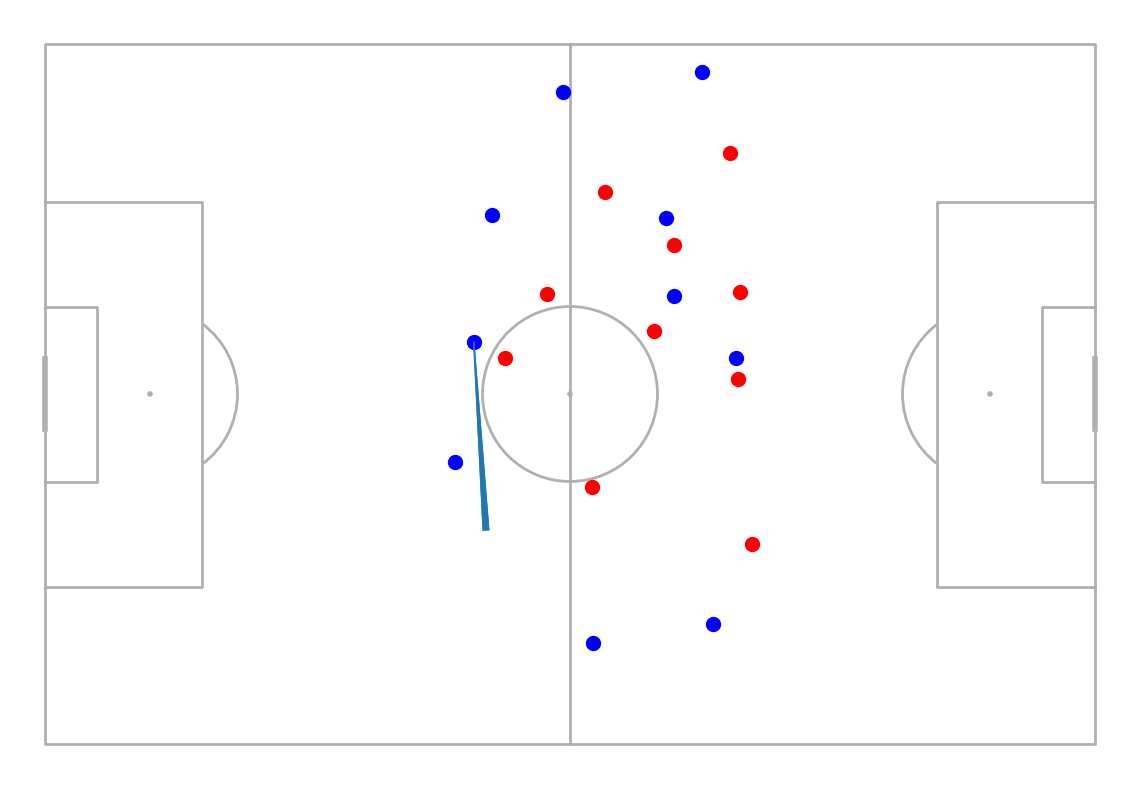

In [19]:
pitch = Pitch(pitch_type='statsbomb')
fig, ax = pitch.draw(figsize=(12,8))

row = 1
dfPlot = dfRodriPass[dfRodriPass['freeze_frame'].notna()].iloc[row]

pitch.scatter(x=dfPlot['xStart'], y=dfPlot['yStart'], ax=ax)
pitch.lines(xstart=dfPlot['xStart'], ystart=dfPlot['yStart'], xend=dfPlot['xEnd'], yend=dfPlot['yEnd'], ax=ax, comet=True)

for player in dfPlot['freeze_frame']:
    if player['teammate']:
        color = 'blue'
    else:
        color = 'red'

    pitch.scatter(x=player['location'][0], y=player['location'][1], ax=ax, c=color, s=100)

In [20]:
def update_plot(row):
    # 1. IMPORTANT: Clear the current figure to prevent stacking/not refreshing
    plt.close('all') 
    
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#aabb97', line_color='white', linewidth=2)
    fig, ax = pitch.draw(figsize=(12, 8))
    
    # Get the data
    dfPlot = dfRodriPass.iloc[row]

    # Extract the extra info
    minute = dfPlot.get('minute', 'N/A')
    # Pressure is often a boolean (True/NaN), handle with .get() or fillna
    under_pressure = "Yes" if dfPlot.get('under_pressure') == 1 else "No"
    pass_outcome = "Complete" if pd.isna(dfPlot.get('pass_outcome')) else dfPlot['pass_outcome']

    # Calculate totals from freeze_frame
    freeze_frame = dfPlot.get('freeze_frame', [])
    teammatesCount = len([p for p in freeze_frame if p['teammate']])
    opponentsCount = len([p for p in freeze_frame if not p['teammate']])

    # Draw your pass
    pitch.scatter(x=dfPlot['xStart'], y=dfPlot['yStart'], ax=ax, c='blue', s=100, zorder=3)
    pitch.lines(xstart=dfPlot['xStart'], ystart=dfPlot['yStart'], 
                xend=dfPlot['xEnd'], yend=dfPlot['yEnd'], 
                ax=ax, comet=True, color='white', lw=3)

    # Draw freeze frame
    if 'freeze_frame' in dfPlot and isinstance(dfPlot['freeze_frame'], list):
        for player in dfPlot['freeze_frame']:
            color = 'green' if player['keeper'] else 'blue' if player['teammate'] else 'red'
            pitch.scatter(x=player['location'][0], y=player['location'][1], 
                          ax=ax, c=color, s=80, edgecolors='white')
    
    # Update Title with the info
    ax.set_title(f"{'Completed' if pd.isna(dfPlot.get('pass_outcome')) else dfPlot['pass_outcome']} pass {row} | Under Pressure: {under_pressure} | Minute: {minute}", 
                 fontsize=16, pad=10)

    # Add Legend with dynamic counts
    # We create empty scatter points just to generate the legend labels
    ax.scatter([], [], c='blue', label=f'Teammates: {teammatesCount}')
    ax.scatter([], [], c='red', label=f'Opponents: {opponentsCount}')
    ax.legend(loc='upper right', fontsize=9, frameon=True)
    
    # 4. Force display
    plt.show()
    
    # Optional: Print details below the plot for easier reading
    #print(f"{'Completed' if pd.isna(dfPlot.get('pass_outcome')) else dfPlot['pass_outcome']} pass {row} | Under Pressure: {under_pressure} | Minute: {minute}")

# Create the interactive slider
interact(update_plot, row=(0, len(dfRodriPass)-1))


interactive(children=(IntSlider(value=15, description='row', max=31), Output()), _dom_classes=('widget-interac…

<function __main__.update_plot(row)>

In [21]:
dfRodriPass.iloc[row]['freeze_frame']

[{'teammate': True,
  'actor': False,
  'keeper': False,
  'location': [46.90530142149434, 47.75402761828062]},
 {'teammate': True, 'actor': True, 'keeper': False, 'location': [49.0, 34.0]},
 {'teammate': True,
  'actor': False,
  'keeper': False,
  'location': [51.12569280787163, 19.59449235334533]},
 {'teammate': False,
  'actor': False,
  'keeper': False,
  'location': [52.604843021659946, 35.8676163311962]},
 {'teammate': False,
  'actor': False,
  'keeper': False,
  'location': [57.341713600363924, 28.62527605214452]},
 {'teammate': True,
  'actor': False,
  'keeper': False,
  'location': [59.18156886846816, 5.442174902124606]},
 {'teammate': False,
  'actor': False,
  'keeper': False,
  'location': [62.56215045246048, 50.61498988318234]},
 {'teammate': True,
  'actor': False,
  'keeper': False,
  'location': [62.59445039910907, 68.44038365280122]},
 {'teammate': False,
  'actor': False,
  'keeper': False,
  'location': [64.0566375752506, 16.954452206893393]},
 {'teammate': False,

In [22]:
dfRodriPassFailed

,duration,id,index,location,match_id,minute,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_end_location,pass_height,pass_length,pass_outcome,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,team,team_id,timestamp,type,under_pressure,event_uuid,visible_area,freeze_frame
190,2.852440,69801875-96e2-4e81-8aa9-8b9f9aa19d88,628,"[31.7, 52.6]",3943043,16,NaN,-0.178879,NaN,Right Foot,"[58.8, 47.7]",High Pass,27.539427,Incomplete,NaN,NaN,NaN,NaN,NaN,1,From Corner,Rodrigo Hernández Cascante,6765.0,Right Defensive Midfield,27,England,768,[83b6adf3-7613-4f6d-bcaa-3c3a9ac86ea9],36,Spain,772,00:16:36.456,Pass,NaN,69801875-96e2-4e81-8aa9-8b9f9aa19d88,"[1.445610457770325, 80.0, 27.950256091428272, ...","[{'teammate': True, 'actor': False, 'keeper': ..."
255,1.799690,9e7ce392-7412-48b8-bd6f-2b60bb3115e1,846,"[36.7, 32.5]",3943043,21,NaN,-0.390250,NaN,Left Foot,"[50.8, 26.7]",High Pass,15.246311,Incomplete,Álvaro Borja Morata Martín,3477.0,NaN,NaN,Recovery,1,From Free Kick,Rodrigo Hernández Cascante,6765.0,Right Defensive Midfield,34,England,768,"[69d80a39-0d4e-43e5-bcb9-6f668e325d00, 7e13134...",54,Spain,772,00:21:54.768,Pass,NaN,9e7ce392-7412-48b8-bd6f-2b60bb3115e1,"[0.0, 80.0, 0.0, 75.71942213956459, 30.9489605...","[{'teammate': True, 'actor': False, 'keeper': ..."
447,0.560557,c341797f-7433-4827-b847-ea5b48efc82a,1556,"[83.0, 53.2]",3943043,40,NaN,0.295441,NaN,Left Foot,"[85.3, 53.9]",Ground Pass,2.404163,Incomplete,Daniel Olmo Carvajal,16532.0,NaN,NaN,NaN,1,From Throw In,Rodrigo Hernández Cascante,6765.0,Right Defensive Midfield,65,Spain,772,"[55cef026-8c40-449b-8f75-fc7e3157a45c, 675ff10...",39,Spain,772,00:40:39.349,Pass,True,c341797f-7433-4827-b847-ea5b48efc82a,"[71.60679135206145, 80.0, 67.05358440569401, 1...","[{'teammate': True, 'actor': False, 'keeper': ..."


# Shots

In [43]:
dfRaw[dfRaw['type'] == 'Shot'].head()

,50_50,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,block_offensive,block_save_block,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,dribble_nutmeg,dribble_outcome,dribble_overrun,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_card,foul_committed_offensive,foul_won_advantage,foul_won_defensive,goalkeeper_body_part,goalkeeper_end_location,goalkeeper_outcome,goalkeeper_position,goalkeeper_technique,goalkeeper_type,id,index,injury_stoppage_in_chain,interception_outcome,location,match_id,minute,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_end_location,pass_goal_assist,pass_height,pass_inswinging,pass_length,pass_no_touch,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_through_ball,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_aerial_won,shot_body_part,shot_deflected,shot_end_location,shot_first_time,shot_freeze_frame,shot_key_pass_id,shot_one_on_one,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure,event_uuid,visible_area,freeze_frame
3228,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.050041,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3787ac1c-b077-4960-b717-ce3e7361f8a4,490,NaN,NaN,"[115.6, 28.4]",3943043,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,From Free Kick,Nicholas Williams Arthuer,68574.0,Left Wing,21,Spain,772,"[29cfd49e-0efa-4bf1-858f-d7d05a555507, 2ccb003...",13,NaN,Left Foot,NaN,"[116.0, 29.3]",NaN,"[{'location': [118.3, 36.0], 'player': {'id': ...",58f991d4-fef8-47d4-a7d3-bfcb2ea6b078,True,Blocked,0.068030,Normal,Open Play,NaN,NaN,NaN,NaN,NaN,Spain,772,00:11:13.568,Shot,True,3787ac1c-b077-4960-b717-ce3e7361f8a4,"[118.50661968971082, 80.0, 94.91181984601062, ...","[{'teammate': False, 'actor': False, 'keeper':..."
3229,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.072991,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,c825856a-5a21-4507-b9e2-ea07b5bf4cca,500,NaN,NaN,"[112.9, 36.2]",3943043,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,From Corner,Robin Aime Robert Le Normand,22128.0,Right Center Back,22,Spain,772,"[0b354f36-d30a-4455-b47d-31594c752317, 1dd307e...",21,NaN,Right Foot,NaN,"[120.0, 29.8, 0.5]",True,"[{'location': [116.0, 40.4], 'player': {'id': ...",0c0e6467-4ce7-4a32-9de2-da2ed79db032,NaN,Off T,0.117465,Overhead Kick,Open Play,NaN,NaN,NaN,NaN,NaN,Spain,772,00:12:21.652,Shot,True,c825856a-5a21-4507-b9e2-ea07b5bf4cca,"[114.21113644631167, 80.0, 93.48173516419142, ...","[{'teammate': True, 'actor': False, 'keeper': ..."
3230,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.076667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,dd4098ae-cd79-4d2a-9717-e95b5fd21674,608,NaN,NaN,"[96.2, 40.8]",3943043,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,From Corner,Declan Rice,3943.0,Left Defensive Midfield,27,England,768,"[a613c9f6-ffab-44b4-bf5c-20c25175f827, cc9bfa1...",20,NaN,Right Foot,NaN,"[98.5, 40.8]",True,"[{'location': [103.6, 56.5], 'player': {'id': ...",86536f69-41fc-4585-b5ee-7a68d6dd4b32,NaN,Blocked,0.048995,Normal,Open Play,NaN,NaN,NaN,NaN,NaN,England,768,00:16:20.810,Shot,True,dd4098ae-cd79-4d2a-9717-e95b5fd21674,"[102.42608525200065, 73.14191525573858, 80.599...","[{'teammate': True, 'actor': False, 'keeper': ..."
3231,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.178330,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7f58b69c-8311-493f-91dd-d2a57ac07387,1047,NaN,NaN,

In [53]:
# eventType: pass, shot, carry
def update_plot(row, df: pd.DataFrame, eventType: str):
    # 1. IMPORTANT: Clear the current figure to prevent stacking/not refreshing
    plt.close('all') 
    
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#aabb97', line_color='white', linewidth=2)
    fig, ax = pitch.draw(figsize=(12, 8))
    
    # Get the data
    dfFiltered = df[df['type'] == eventType.capitalize()]
    dfFiltered[['xStart','yStart']] = pd.DataFrame(dfFiltered.location.tolist(), index=dfFiltered.index)
    #dfFiltered[['xEnd','yEnd']] = pd.DataFrame(dfFiltered[eventType + "_end_location"].tolist(), index=dfFiltered.index)
    # The "shot" can have a z-value sometimes
    dfFiltered[['xEnd', 'yEnd', 'zEnd']] = pd.DataFrame(
        [loc + [float('nan')] * (3 - len(loc)) for loc in dfFiltered[eventType + "_end_location"]],
        index=dfFiltered.index)
    dfPlot = dfFiltered.iloc[row]

    # Extract the extra info
    minute = dfPlot.get('minute', 'N/A')
    # Pressure is often a boolean (True/NaN), handle with .get() or fillna
    under_pressure = "Yes" if dfPlot.get('under_pressure') == 1 else "No"
    outcome = "Complete" if pd.isna(dfPlot.get(eventType + '_outcome')) else dfPlot[eventType + '_outcome']
    playerName = dfPlot['player']

    # Calculate totals from freeze_frame
    freeze_frame = dfPlot.get('freeze_frame', [])
    if not isinstance(freeze_frame, list):
        freeze_frame = []  # Default to an empty list if it's not a valid list
    teammatesCount = len([p for p in freeze_frame if p['teammate']])
    opponentsCount = len([p for p in freeze_frame if not p['teammate']])

    # Draw your pass
    pitch.scatter(x=dfPlot['xStart'], y=dfPlot['yStart'], ax=ax, c='blue', s=100, zorder=3)
    pitch.lines(xstart=dfPlot['xStart'], ystart=dfPlot['yStart'], 
                xend=dfPlot['xEnd'], yend=dfPlot['yEnd'], 
                ax=ax, comet=True, color='white', lw=3)

    # Draw freeze frame
    if 'freeze_frame' in dfPlot and isinstance(dfPlot['freeze_frame'], list):
        for player in dfPlot['freeze_frame']:
            color = 'green' if player['keeper'] else 'blue' if player['teammate'] else 'red'
            pitch.scatter(x=player['location'][0], y=player['location'][1], 
                          ax=ax, c=color, s=80, edgecolors='white')
    
    # Update Title with the info
    # Check if zEnd is not NaN
    z_value = dfPlot['zEnd']
    z_text = f" | z: {z_value:.2f}" if pd.notna(z_value) else ""
    ax.set_title(f"{playerName} | {outcome} {eventType} {row} | Under Pressure: {under_pressure} | Minute: {minute}{z_text}", 
                 fontsize=16, pad=10)

    # Add Legend with dynamic counts
    # We create empty scatter points just to generate the legend labels
    ax.scatter([], [], c='blue', label=f'Teammates: {teammatesCount}')
    ax.scatter([], [], c='red', label=f'Opponents: {opponentsCount}')
    ax.legend(loc='upper right', fontsize=9, frameon=True)
    
    # 4. Force display
    plt.show()
    
    # Optional: Print details below the plot for easier reading
    #print(f"{'Completed' if pd.isna(dfPlot.get(eventType + '_outcome')) else dfPlot[eventType + '_outcome']} pass {row} | Under Pressure: {under_pressure} | Minute: {minute}")

# Create the interactive slider
interact(update_plot, row=(0, len(dfRaw[dfRaw['type'] == eventType.capitalize()]) - 1), df=fixed(dfRaw), eventType=fixed('shot'))

interactive(children=(IntSlider(value=12, description='row', max=24), Output()), _dom_classes=('widget-interac…

<function __main__.update_plot(row, df: pandas.DataFrame, eventType: str)>

# Passing network graph

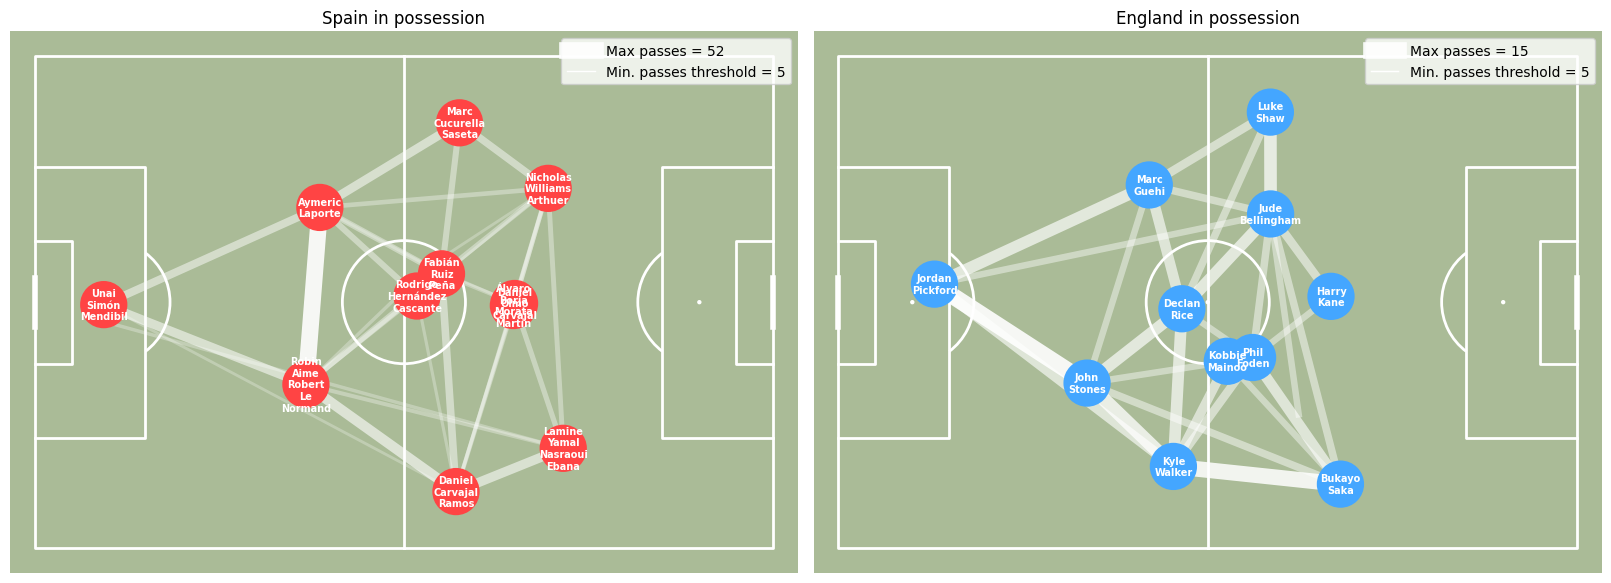

In [49]:
# Helper function to extract names from nested dictionaries
def extract_name(obj):
    if isinstance(obj, dict):
        return obj.get('name', 'Unknown')
    return str(obj)

def ShowPassingNetwork(dataframe, team: int, dfForTeam=None, minPasses=5, showPassesCount=False, ax=None):
    if not isinstance(team, int):
        raise TypeError(f"{team=} must be an int, got {type(team).__name__}")
    if not isinstance(minPasses, int):
        raise TypeError(f"{minPasses=} must be an int, got {type(minPasses).__name__}")
    if not isinstance(showPassesCount, bool):
        raise TypeError(f"{showPassesCount=} must be a bool, got {type(showPassesCount).__name__}")

    if dfForTeam is None:
        dfForTeam = dataframe.copy()

    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 8))

    # Clean up data structure
    dataframe['team_name'] = dataframe['team'].apply(extract_name)
    dataframe['player_name'] = dataframe['player'].apply(lambda x: extract_name(x) if x is not None else None)
    dataframe['event_type'] = dataframe['type'].apply(extract_name)
    
    # Filter team data
    dfForTeam['team_name'] = dfForTeam['team'].apply(extract_name)
    team_name = dfForTeam['team_name'].unique()[team]
    team_events = dataframe[dataframe['team_name'] == team_name]
    passes_df = team_events[team_events['type'] == 'Pass']
    
    # Calculate average positions
    player_positions = defaultdict(list)
    for idx, event in team_events.iterrows():
        player = event.get('player_name')
        location = event.get('location')
        if player and location and isinstance(location, list) and len(location) == 2:
            player_positions[player].append(location)
            
    # Get average positions for active players
    passesThreshold = 1
    avg_positions = {}
    for player, positions in player_positions.items():
        if len(positions) >= passesThreshold:
            positions_array = np.array(positions)
            avg_x = np.mean(positions_array[:, 0])
            avg_y = np.mean(positions_array[:, 1])
            avg_positions[player] = (avg_x, avg_y)
    
    # Calculate pass connections
    pass_connections = defaultdict(int)
    for idx, pass_event in passes_df.iterrows():
        passer = pass_event.get('player_name')
        recipient_info = pass_event.get('pass_recipient')
        receiver = extract_name(recipient_info) if recipient_info else None
    
        # Check if pass was successful ([nan, 'Out', 'Incomplete', 'Unknown', 'Pass Offside'])
        passIsSuccessful = pd.notna(pass_event.get('pass_outcome'))
        passIsSuccessful = True
    
        if (passer and receiver and passIsSuccessful and
            passer in avg_positions and receiver in avg_positions):
            key = tuple(sorted((passer, receiver)))
            pass_connections[key] += 1
    
    # Filter significant connections
    significant_connections = {passerReceiver: passesCount for passerReceiver, passesCount in pass_connections.items() if passesCount >= minPasses}
    
    passesMax = max(significant_connections.values()) if significant_connections else 1
    
    # Create visualization
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#aabb97', line_color='white', linewidth=2)
    pitch.draw(ax=ax)
    
    # Draw pass connections with thickness based on frequency
    for (passer, receiver), passesCount in significant_connections.items():
        passer_pos = avg_positions[passer]
        receiver_pos = avg_positions[receiver]
    
        line_thickness = 1 + (passesCount / passesMax) * 11
        alpha = 0.2 + (passesCount / passesMax) * 0.7
    
        ax.plot([passer_pos[0], receiver_pos[0]], [passer_pos[1], receiver_pos[1]],
               color='white', linewidth=line_thickness, alpha=alpha, zorder=2)

        if showPassesCount:
            mid_x = (passer_pos[0] + receiver_pos[0]) / 2
            mid_y = (passer_pos[1] + receiver_pos[1]) / 2
            ax.text(mid_x, mid_y, str(passesCount), color='black', fontsize=9, fontweight='bold', ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.8), zorder=3)
    
    # Draw player nodes (top 11 most active)
    top_players = sorted(avg_positions.items(),
                        key=lambda x: len(player_positions[x[0]]), reverse=True)[:11]
    
    for i, (player, (x, y)) in enumerate(top_players):
        circleColor = '#FF4444' if team == 0 else '#44A6FF'
        circle = plt.Circle((x, y), radius=3.5, color=circleColor,
                           edgecolor='white', linewidth=3, zorder=5)
        ax.add_patch(circle)
    
        playerNames = '\n'.join(player.split())
        ax.text(x, y, playerNames, color='white', fontweight='bold',
               ha='center', va='center', fontsize=7, zorder=6)
    
    # Show title & legend
    ax.set_title(f"{team_name} passing network",  fontsize=18, pad=10)
    max_entry = Line2D([0], [0], color='white', linewidth=1 + 11, alpha=0.9, label=f"Max passes = {passesMax}")
    minimumPassCountThreshold = Line2D([], [], color='white', linewidth=1 + (1 / passesMax),
                                       label=f"Min. passes threshold = {minPasses}")
    ax.legend(handles=[max_entry, minimumPassCountThreshold], loc='upper right')
    
    return ax



dfSpainPossession = dfRaw[dfRaw['possession_team'] == 'Spain']
dfEnglandPossession = dfRaw[dfRaw['possession_team'] == 'England']

fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)

ShowPassingNetwork(dfSpainPossession, team=0, dfForTeam=dfRaw, minPasses=5, showPassesCount=False, ax=axes[0])
axes[0].set_title("Spain in possession")

ShowPassingNetwork(dfEnglandPossession, team=1, dfForTeam=dfRaw, minPasses=5, showPassesCount=False, ax=axes[1])
axes[1].set_title("England in possession")

plt.show()

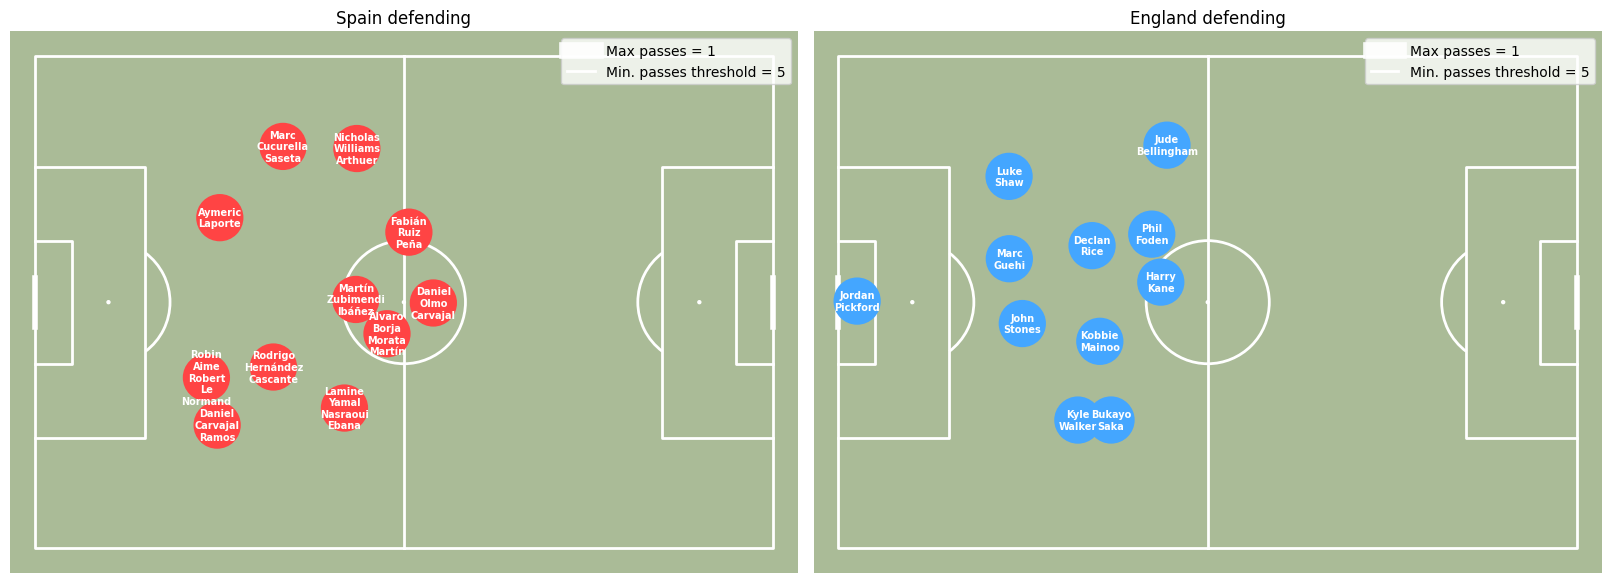

In [48]:
dfSpainDefense = dfRaw[dfRaw['possession_team'] == 'England']
dfEnglandDefense = dfRaw[dfRaw['possession_team'] == 'Spain']

fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)

ShowPassingNetwork(dfSpainDefense, team=0, dfForTeam=dfRaw, minPasses=5, showPassesCount=False, ax=axes[0])
axes[0].set_title("Spain defending")

ShowPassingNetwork(dfEnglandDefense, team=1, dfForTeam=dfRaw, minPasses=5, showPassesCount=False, ax=axes[1])
axes[1].set_title("England defending")

plt.show()

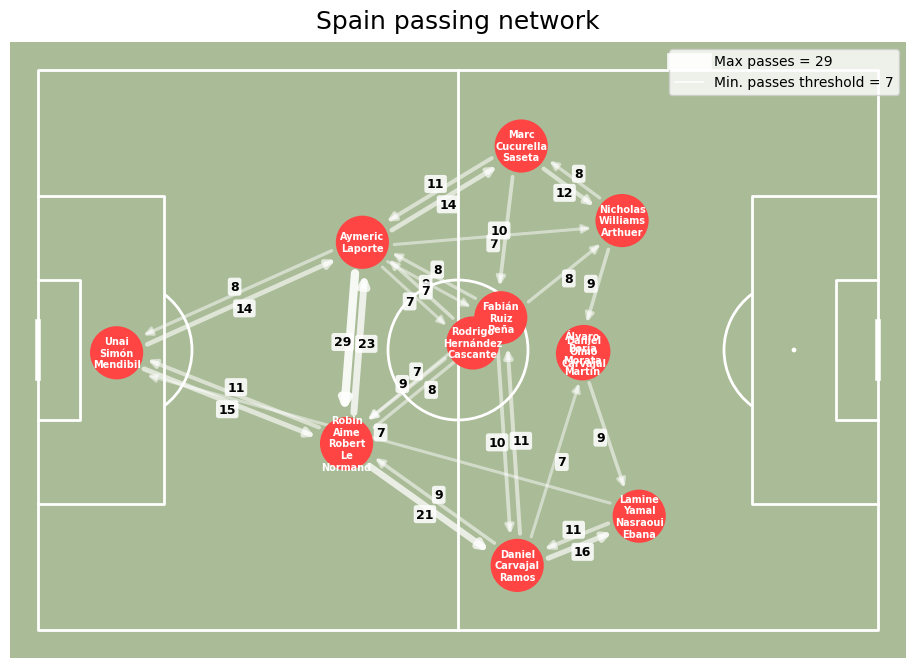

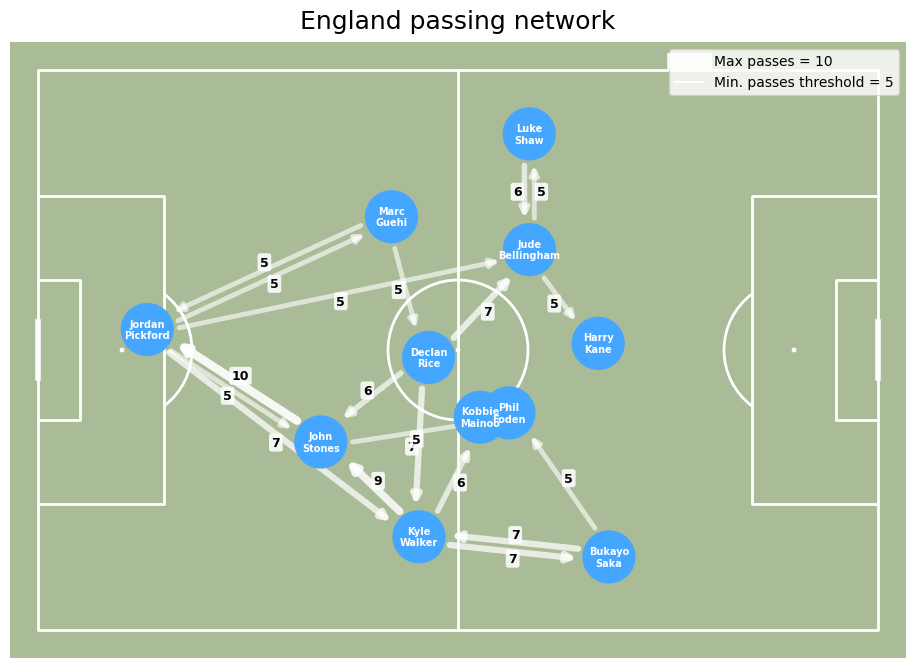

In [76]:
# Helper function to extract names from nested dictionaries
def extract_name(obj):
    if isinstance(obj, dict):
        return obj.get('name', 'Unknown')
    return str(obj)

def ShowDirectionalPassingNetwork(dataframe, team: int, dfForTeam=None, row_filter=None, minPasses=5, showPassesCount=True, ax=None):
    if not isinstance(team, int):
        raise TypeError(f"{team=} must be an int, got {type(team).__name__}")
    if not isinstance(minPasses, int):
        raise TypeError(f"{minPasses=} must be an int, got {type(minPasses).__name__}")
    if not isinstance(showPassesCount, bool):
        raise TypeError(f"{showPassesCount=} must be a bool, got {type(showPassesCount).__name__}")
        
    if dfForTeam is None:
        dfForTeam = dataframe.copy()

    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 8))

    node_radius = 3.5
    gap = 0.6
    shorten = node_radius + gap         # trim near each node
    arrow_offset = 0.7                  # separation between the two arrows
    label_offset = 2.0                  # how far labels sit from each arrow

    # Clean up data structure
    dataframe['team_name'] = dataframe['team'].apply(extract_name)
    dataframe['player_name'] = dataframe['player'].apply(lambda x: extract_name(x) if x is not None else None)
    dataframe['event_type'] = dataframe['type'].apply(extract_name)

    # Filter team data
    dfForTeam['team_name'] = dfForTeam['team'].apply(extract_name)
    team_name = dfForTeam['team_name'].unique()[team]
    team_events = dataframe[dataframe['team_name'] == team_name] 
    passes_df = team_events[team_events['type'] == 'Pass']
    
    # Calculate average positions
    player_positions = defaultdict(list)
    for idx, event in team_events.iterrows():
        player = event.get('player_name')
        location = event.get('location')
        if player and location and isinstance(location, list) and len(location) == 2:
            player_positions[player].append(location)
            
    # Get average positions for active players
    passesThreshold = 1
    avg_positions = {}
    for player, positions in player_positions.items():
        if len(positions) >= passesThreshold:
            positions_array = np.array(positions)
            avg_x = np.mean(positions_array[:, 0])
            avg_y = np.mean(positions_array[:, 1])
            avg_positions[player] = (avg_x, avg_y)
    
    # Calculate pass connections
    pass_connections = defaultdict(int)
    for idx, pass_event in passes_df.iterrows():
        passer = pass_event.get('player_name')
        recipient_info = pass_event.get('pass_recipient')
        receiver = extract_name(recipient_info) if recipient_info else None
    
        # Check if pass was successful ([nan, 'Out', 'Incomplete', 'Unknown', 'Pass Offside'])
        passIsSuccessful = pd.notna(pass_event.get('pass_outcome'))
        passIsSuccessful = True
    
        if (passer and receiver and passIsSuccessful and
            passer in avg_positions and receiver in avg_positions):
            pass_connections[(passer, receiver)] += 1

    
    merged_connections = defaultdict(int)
    for (passer, receiver), count in pass_connections.items():
        key = tuple(sorted((passer, receiver)))  # ('A','B') == ('B','A')
        merged_connections[key] += count
    
    # Filter significant connections
    significant_connections = {passerReceiver: passesCount for passerReceiver, passesCount in pass_connections.items() if passesCount >= minPasses}
    
    passesMax = max(significant_connections.values()) if significant_connections else 1
    
    # Create visualization
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#aabb97', line_color='white', linewidth=2)
    pitch.draw(ax=ax)
    
    # Draw pass connections with thickness based on frequency
    handled = set()
    
    for (passer, receiver), count_ab in significant_connections.items():
        if (receiver, passer) in handled:
            continue
    
        pos_a = np.array(avg_positions[passer], dtype=float)
        pos_b = np.array(avg_positions[receiver], dtype=float)
        vec = pos_b - pos_a
        dist = np.linalg.norm(vec)
        if dist <= 2 * shorten:
            continue  # too close
    
        direction = vec / dist
        base_start = pos_a + direction * shorten
        base_end = pos_b - direction * shorten
        segment = base_end - base_start
        seg_len = np.linalg.norm(segment)
        perp = np.array([-segment[1], segment[0]]) / seg_len

        scale = 5
        # forward arrow (passer -> receiver)
        start_ab = base_start + perp * arrow_offset
        end_ab = base_end + perp * arrow_offset
        width_ab = 1 + (count_ab / passesMax) * scale
        alpha_ab = 0.35 + (count_ab / passesMax) * 0.55
        arrow_ab = FancyArrowPatch(
            start_ab,
            end_ab,
            arrowstyle='-|>',
            mutation_scale=12,
            linewidth=width_ab,
            color='white',
            alpha=alpha_ab,
            zorder=4,
        )
        ax.add_patch(arrow_ab)
    
        # reverse arrow (receiver -> passer)
        count_ba = significant_connections.get((receiver, passer), 0)
        if count_ba:
            start_ba = base_end - perp * arrow_offset
            end_ba = base_start - perp * arrow_offset
            width_ba = 1 + (count_ba / passesMax) * scale
            alpha_ba = 0.35 + (count_ba / passesMax) * 0.55
            arrow_ba = FancyArrowPatch(
                start_ba,
                end_ba,
                arrowstyle='-|>',
                mutation_scale=12,
                linewidth=width_ba,
                color='white',
                alpha=alpha_ba,
                zorder=4,
            )
            ax.add_patch(arrow_ba)
    
        # labels aligned with corresponding arrows
        bbox = dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.85)
        mid_ab = (start_ab + end_ab) / 2
        ax.text(* (mid_ab + perp * label_offset / 2), str(count_ab),
                ha='center', va='center', fontsize=9, fontweight='bold',
                color='black', bbox=bbox, zorder=5)
    
        if count_ba:
            mid_ba = (start_ba + end_ba) / 2
            ax.text(* (mid_ba - perp * label_offset / 2), str(count_ba),
                    ha='center', va='center', fontsize=9, fontweight='bold',
                    color='black', bbox=bbox, zorder=5)
    
        handled.update({(passer, receiver), (receiver, passer)})    
        
    # Draw player nodes (top 11 most active)
    top_players = sorted(avg_positions.items(),
                        key=lambda x: len(player_positions[x[0]]), reverse=True)[:11]
    
    for i, (player, (x, y)) in enumerate(top_players):
        circleColor = '#FF4444' if team == 0 else '#44A6FF'
        circle = plt.Circle((x, y), radius=3.5, color=circleColor,
                           edgecolor='white', linewidth=3, zorder=5)
        ax.add_patch(circle)
    
        playerNames = '\n'.join(player.split())
        ax.text(x, y, playerNames, color='white', fontweight='bold',
               ha='center', va='center', fontsize=7, zorder=6)
        
    # Show title & legend
    ax.set_title(f"{team_name} passing network",  fontsize=18, pad=10)
    max_entry = Line2D([0], [0], color='white', linewidth=1 + 11, alpha=0.9, label=f"Max passes = {passesMax}")
    minimumPassCountThreshold = Line2D([], [], color='white', linewidth=1 + (1 / passesMax) * scale,
                                       label=f"Min. passes threshold = {minPasses}")
    ax.legend(handles=[max_entry, minimumPassCountThreshold], loc='upper right')
    
    return (ax, pass_connections, merged_connections)



dfSpainPossession = dfRaw[dfRaw['possession_team'] == 'Spain']
dfEnglandPossession = dfRaw[dfRaw['possession_team'] == 'England']
    
(networkPlot, passConnections, mergedPassConnections) = ShowDirectionalPassingNetwork(dfSpainPossession, team=0, dfForTeam=dfRaw, minPasses=7, showPassesCount=False, ax=None)
(networkPlot, passConnections, mergedPassConnections) = ShowDirectionalPassingNetwork(dfEnglandPossession, team=1, dfForTeam=dfRaw, minPasses=5, showPassesCount=False, ax=None)

In [ ]:
dfEnglandPossession

In [29]:
#passConnections
#mergedPassConnections
#significantConnections = {passerReceiver: passesCount for passerReceiver, passesCount in passConnections.items() if passesCount >= 5}
#significantConnections = {passerReceiver: passesCount for passerReceiver, passesCount in mergedPassConnections.items() if passesCount >= 5}
#{passerReceiver: passesCount for passerReceiver, passesCount in passConnections.items() if passesCount >= 5}
{passerReceiver: passesCount for passerReceiver, passesCount in mergedPassConnections.items() if passesCount >= 10}

{('Robin Aime Robert Le Normand', 'Unai Simón Mendibil'): 26,
 ('Daniel Carvajal Ramos', 'Robin Aime Robert Le Normand'): 30,
 ('Daniel Carvajal Ramos', 'Daniel Olmo Carvajal'): 10,
 ('Robin Aime Robert Le Normand', 'Rodrigo Hernández Cascante'): 12,
 ('Aymeric Laporte', 'Robin Aime Robert Le Normand'): 52,
 ('Aymeric Laporte', 'Unai Simón Mendibil'): 22,
 ('Aymeric Laporte', 'Rodrigo Hernández Cascante'): 16,
 ('Daniel Carvajal Ramos', 'Lamine Yamal Nasraoui Ebana'): 27,
 ('Aymeric Laporte', 'Marc Cucurella Saseta'): 25,
 ('Aymeric Laporte', 'Nicholas Williams Arthuer'): 11,
 ('Marc Cucurella Saseta', 'Nicholas Williams Arthuer'): 21,
 ('Fabián Ruiz Peña', 'Marc Cucurella Saseta'): 16,
 ('Aymeric Laporte', 'Fabián Ruiz Peña'): 15,
 ('Fabián Ruiz Peña', 'Nicholas Williams Arthuer'): 13,
 ('Daniel Olmo Carvajal', 'Nicholas Williams Arthuer'): 10,
 ('Fabián Ruiz Peña', 'Robin Aime Robert Le Normand'): 15,
 ('Daniel Carvajal Ramos', 'Fabián Ruiz Peña'): 21,
 ('Nicholas Williams Arthuer', 

In [79]:
def ShowEventTypeScatter(dataframe, team: int, event: int | None = None, ax=None):
    if not isinstance(team, int):
        raise TypeError(f"{team=} must be an int, got {type(team).__name__}")
    if event is not None and not isinstance(event, str):
        raise TypeError(f"{event=} must be a string, got {type(event).__name__}")

    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 8))

    # draw pitch background
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#aabb97',
                  line_color='white', linewidth=2)
    pitch.draw(ax=ax)

    dataframe['event_name'] = dataframe['type'].apply(
        lambda x: x['name'] if isinstance(x, dict) else str(x)
    )
    dataframe['team_name'] = dataframe['team'].apply(
        lambda x: x['name'] if isinstance(x, dict) else str(x)
    )

    team_name = dataframe['team_name'].unique()[team]
    team_df = dataframe[dataframe['team_name'] == team_name]

    event_colors = {
        'Pass': 'blue', 'Ball Receipt*': 'green', 'Carry': 'orange',
        'Pressure': 'red', 'Ball Recovery': 'purple', 'Clearance': 'brown'
    }
    event_markers = {
        'Pass': 'o', 'Ball Receipt*': 's', 'Carry': '^',
        'Pressure': 'x', 'Ball Recovery': 'd', 'Clearance': 'v'
    }

    unique_events = sorted(team_df['event_name'].unique())
    if not unique_events:
        return ax

    if event is None:
        target_events = unique_events
        legend_suffix = "All events"
    else:
        if event not in unique_events:
            raise ValueError(f"{event=} not found for team {team_name}")
        target_events = [event]
        legend_suffix = event
        
    handles, labels = ax.get_legend_handles_labels()

    for event_type in target_events:
        subset = team_df[team_df['event_name'] == event_type]
        color = event_colors.get(event_type, 'gray')
        marker = event_markers.get(event_type, 'o')

        # only add legend entry once per event_type
        add_label = event_type not in labels
        for _, row in subset.iterrows():
            location = row['location']
            if isinstance(location, (list, tuple)) and len(location) == 2:
                x, y = location
                ax.scatter(
                    x, y,
                    c=color,
                    marker=marker,
                    s=50,
                    alpha=0.7,
                    edgecolors='black',
                    label=event_type if add_label else ""
                )
                add_label = False

    ax.set_title(f"{team_name} – Event Types ({legend_suffix})")
    ax.legend(loc='upper right', fontsize=9, frameon=False)

    return ax

<Axes: title={'center': 'England – Event Types (Shot)'}>

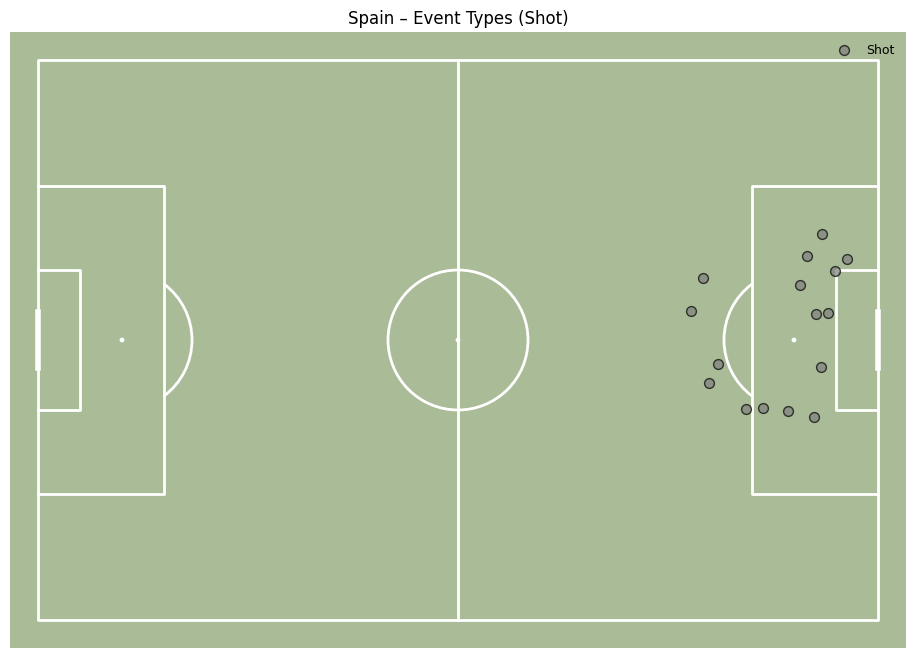

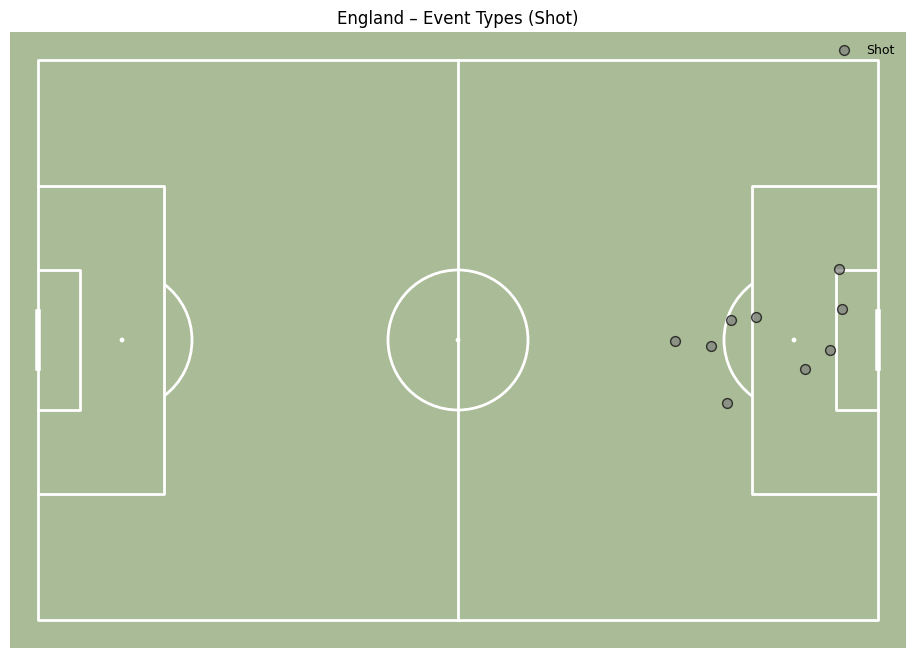

In [80]:
# 50/50, ball receipt, ball recovery, block, carry, clearance, dispossessed,
# dribble, dribbled past, duel, error, foul comitted, foul won,
# interception, miscontrol, pass, pressure, shield, shot,
# 
# goal keeper, half end, half start, injury stoppage, referee ball-drop, starting XI, substitution, tactical shift,
ShowEventTypeScatter(dfRaw, team=0, event='Shot', ax=None)
ShowEventTypeScatter(dfRaw, team=1, event='Shot', ax=None)

In [82]:
dfRaw[dfRaw['type'] == 'Tactical Shift']

,50_50,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,block_offensive,block_save_block,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,dribble_nutmeg,dribble_outcome,dribble_overrun,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_card,foul_committed_offensive,foul_won_advantage,foul_won_defensive,goalkeeper_body_part,goalkeeper_end_location,goalkeeper_outcome,goalkeeper_position,goalkeeper_technique,goalkeeper_type,id,index,injury_stoppage_in_chain,interception_outcome,location,match_id,minute,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_end_location,pass_goal_assist,pass_height,pass_inswinging,pass_length,pass_no_touch,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_through_ball,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_aerial_won,shot_body_part,shot_deflected,shot_end_location,shot_first_time,shot_freeze_frame,shot_key_pass_id,shot_one_on_one,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure,event_uuid,visible_area,freeze_frame,team_name,player_name,event_type,event_name
3308,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,d243577a-f17f-4028-b408-77e5d51f67ae,2594,NaN,NaN,NaN,3943043,69,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,From Goal Kick,NaN,NaN,NaN,111,England,768,NaN,58,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'formation': 4231, 'lineup': [{'player': {'id...",England,768,00:24:58.861,Tactical Shift,NaN,NaN,NaN,NaN,England,nan,Tactical Shift,Tactical Shift
3309,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,53c7cfe2-9916-4a07-a7ec-51470ff54d93,3259,NaN,NaN,NaN,3943043,89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,From Corner,NaN,NaN,NaN,138,England,768,NaN,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'formation': 41212, 'lineup': [{'player': {'i...",England,768,00:44:20.041,Tactical Shift,NaN,NaN,NaN,NaN,England,nan,Tactical Shift,Tactical Shift
3310,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,812eea9d-b613-45f1-91df-76bebd97d295,3260,NaN,NaN,NaN,3943043,89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,From Corner,NaN,NaN,NaN,138,England,768,NaN,54,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'formation': 4231, 'lineup': [{'player': {'id...",Spain,772,00:44:54.242,Tactical Shift,NaN,NaN,NaN,NaN,Spain,nan,Tactical Shift,Tactical Shift


In [88]:
dfRaw[dfRaw['tactics'].notna()][['tactics','minute']]

,tactics,minute
0,"{'formation': 4231, 'lineup': [{'player': {'id...",0
1,"{'formation': 4231, 'lineup': [{'player': {'id...",0
3308,"{'formation': 4231, 'lineup': [{'player': {'id...",69
3309,"{'formation': 41212, 'lineup': [{'player': {'i...",89
3310,"{'formation': 4231, 'lineup': [{'player': {'id...",89


In [91]:
dfRaw.loc[dfRaw['tactics'].notna(), 'tactics']

0       {'formation': 4231, 'lineup': [{'player': {'id...
1       {'formation': 4231, 'lineup': [{'player': {'id...
3308    {'formation': 4231, 'lineup': [{'player': {'id...
3309    {'formation': 41212, 'lineup': [{'player': {'i...
3310    {'formation': 4231, 'lineup': [{'player': {'id...
Name: tactics, dtype: object